# Filter Explorer
### Calibración de parámetros de filtrado por dataset
**Flujo:**
1. Configura el dataset en la Celda 2
2. Ejecuta la Celda 3 para encontrar la imagen más representativa
3. Explora umbrales en las Celdas 4–6
4. Copia la configuración final desde la Celda 7

## Celda 1 — Imports

In [22]:
import sys, random, warnings
from pathlib import Path

sys.path.insert(0, '/home/shared_data/vmieres/tesis')
warnings.filterwarnings('ignore')

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from tqdm.notebook import tqdm

Image.MAX_IMAGE_PIXELS = None

from patch_extractor import (
    WSIReader, compute_tissue_mask_gpu,
    generate_patch_coords, map_patch_to_mask
)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cpu


## Celda 2 — Configuración del dataset a explorar
**Edita solo esta celda para cambiar de dataset.**

In [23]:
# ══════════════════════════════════════════════════════════════
# EDITA AQUÍ
# ══════════════════════════════════════════════════════════════

DATASET_NAME = 'Surgen'   # nombre para logs y config final

DATASET_PATH = '/home/shared_data/SurGen'
FILE_FORMAT  = 'czi'      # jpg | tiff | mrxs | czi
STRUCTURE    = 'split_folders'     # flat | case_folders | split_folders

TARGET_MAG   = 20.0
PATCH_SIZE   = 224
THUMB_SIZE   = (512, 512)   # resolución de miniatura para análisis

# Cuántas imágenes escanear para encontrar la representativa
# Si el dataset es grande, un sample de 50-100 es suficiente
MAX_SCAN     = 80

# ══════════════════════════════════════════════════════════════

# Ejemplos para cada dataset:
# ─────────────────────────────────────────────────────────────
# BCNB:
#   PATH      = '/home/DIINF/datasets_iacis/2026_BCNB/WSIs'
#   FORMAT    = 'jpg'
#   STRUCTURE = 'flat'
#
# HistologyHSI:
#   PATH      = '/home/DIINF/vmieres/PKG - HistologyHSI-BC-Recurrence/01_01_Histological_Images'
#   FORMAT    = 'mrxs'
#   STRUCTURE = 'flat'
#
# HISTAI_Breast / HISTAI_Colorectal_B1 / HISTAI_Colorectal_B2:
#   PATH      = '/home/DIINF/datasets_iacis/2026_HISTAI/HISTAI_Breast'
#   FORMAT    = 'tiff'
#   STRUCTURE = 'case_folders'
#
# SurGen:
#   PATH      = '/home/DIINF/datasets_iacis/2026_SurGen'
#   FORMAT    = 'czi'
#   STRUCTURE = 'split_folders'
# ─────────────────────────────────────────────────────────────

print(f'Dataset configurado: {DATASET_NAME}')
print(f'Ruta: {DATASET_PATH}')

Dataset configurado: Surgen
Ruta: /home/shared_data/SurGen


In [24]:
def discover_files(path, fmt, structure):
    base = Path(path)
    ext_map = {'jpg': ['*.jpg','*.jpeg'], 'tiff': ['*.tiff','*.tif'],
               'mrxs': ['*.mrxs'], 'czi': ['*.czi']}
    patterns = ext_map.get(fmt.lower(), [f'*.{fmt}'])
    files = []
    if structure == 'flat':
        for p in patterns: files.extend(base.glob(p))
    elif structure == 'case_folders':
        for d in sorted(base.iterdir()):
            if d.is_dir():
                for p in patterns: files.extend(d.glob(p))
    elif structure == 'split_folders':
        for d in sorted(base.iterdir()):
            if d.is_dir():
                for p in patterns: files.extend(d.glob(p))
    return sorted(files)


def compute_representativeness_score(thumb_rgb):
    """
    Calcula métricas de representatividad sobre una miniatura RGB.
    Retorna dict con: tissue_pct, hematoxylin_pct, eosin_pct, color_diversity, brightness
    """
    t = torch.from_numpy(thumb_rgb).float().to(device) / 255.0  # (H, W, 3)

    # % tejido via Otsu
    gray = 0.2989*t[...,0] + 0.5870*t[...,1] + 0.1140*t[...,2]
    hist = torch.histc(gray.flatten(), bins=256, min=0, max=1)
    total = gray.numel()
    cumsum = torch.cumsum(hist, dim=0)
    cw = torch.cumsum(hist * torch.linspace(0,1,256,device=device), dim=0)
    gm = cw[-1]
    w0 = cumsum/total; w1 = 1-w0
    mu0 = cw/(cumsum+1e-10); mu1 = (gm-cw)/(w1+1e-10)
    otsu = (torch.argmax(w0*w1*(mu0-mu1)**2).float()/255.0).item()
    # Auto-detectar fondo oscuro (microscopia CZI) vs claro (scanner)
    dark_bg = gray.median().item() < 0.3
    if dark_bg:
        tissue_pct = float((gray > otsu).float().mean().cpu())
    else:
        tissue_pct = float((gray < otsu).float().mean().cpu())

    # Separar hematoxilina (azul/violeta) y eosina (rosa/rojo) via color
    r, g, b = t[...,0], t[...,1], t[...,2]
    tissue_mask = (gray > otsu) if dark_bg else (gray < otsu)
    if tissue_mask.sum() > 0:
        tr = r[tissue_mask]; tg = g[tissue_mask]; tb = b[tissue_mask]
        # Hematoxilina: B > R y B > G (azul dominante)
        hema = ((tb > tr) & (tb > tg)).float().mean().item()
        # Eosina: R > B y R > G (rosa/rojo dominante)
        eosin = ((tr > tb) & (tr > tg)).float().mean().item()
    else:
        hema, eosin = 0.0, 0.0

    # Diversidad de color (std del histograma de saturación)
    cmax = torch.maximum(torch.maximum(r,g),b)
    cmin = torch.minimum(torch.minimum(r,g),b)
    sat = (cmax-cmin)/(cmax+1e-8)
    color_diversity = float(sat.std().cpu())

    # Brillo medio
    brightness = float(gray.mean().cpu())

    return {
        'tissue_pct': tissue_pct,
        'hema_pct': hema,
        'eosin_pct': eosin,
        'color_diversity': color_diversity,
        'brightness': brightness
    }


# ── Descubrir archivos ────────────────────────────────────────────────────────
all_files = discover_files(DATASET_PATH, FILE_FORMAT, STRUCTURE)
print(f'Total archivos encontrados: {len(all_files)}')

# Sample aleatorio si el dataset es muy grande
if len(all_files) > MAX_SCAN:
    scan_files = random.sample(all_files, MAX_SCAN)
    print(f'Escaneando muestra aleatoria de {MAX_SCAN} archivos...')
else:
    scan_files = all_files
    print(f'Escaneando todos los {len(scan_files)} archivos...')

# ── Escanear miniaturas y calcular métricas ───────────────────────────────────
records = []
errors  = []

for fpath in tqdm(scan_files, desc='Escaneando'):
    try:
        reader = WSIReader(str(fpath), target_magnification=TARGET_MAG)
        thumb  = reader.get_thumbnail(THUMB_SIZE)
        dims   = reader.dimensions
        reader.close()
        metrics = compute_representativeness_score(thumb)
        metrics['path']   = str(fpath)
        metrics['name']   = fpath.stem
        metrics['width']  = dims[0]
        metrics['height'] = dims[1]
        metrics['n_pixels'] = dims[0] * dims[1]
        metrics['thumb']  = thumb
        records.append(metrics)
    except Exception as e:
        errors.append((str(fpath), str(e)))

print(f'\nEscaneadas: {len(records)} | Errores: {len(errors)}')
if errors:
    print('Errores:', [e[0].split("/")[-1] for e in errors[:5]])

Total archivos encontrados: 1020
Escaneando muestra aleatoria de 80 archivos...


Escaneando:   0%|          | 0/80 [00:00<?, ?it/s]


Escaneadas: 77 | Errores: 3
Errores: ['SR386_40X_HE_T531_01.czi', 'SR386_40X_HE_T523_01.czi', 'SR386_40X_HE_T522_01.czi']


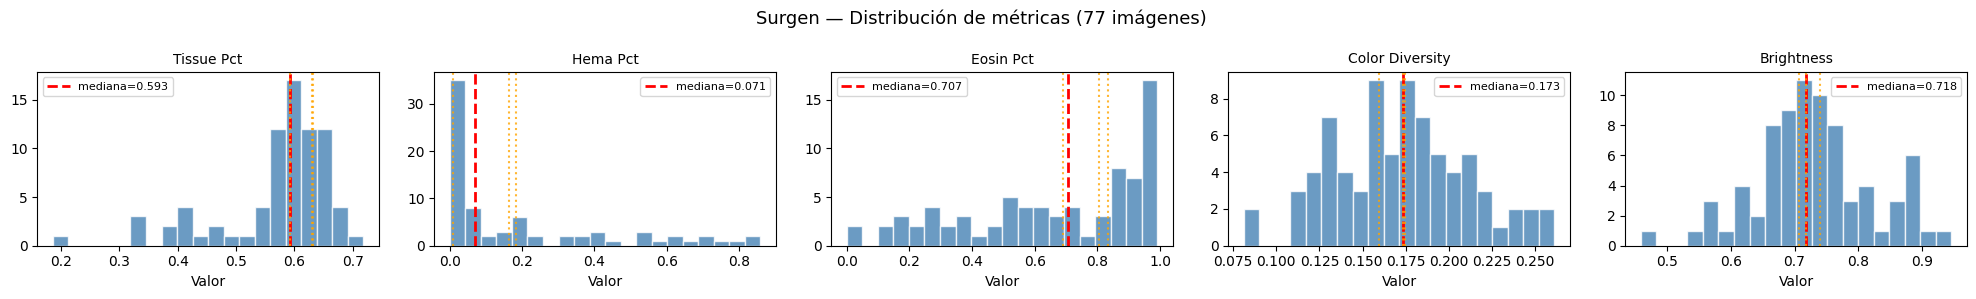


🏆 Top-3 imágenes más representativas del dataset:
#    Nombre                                Tejido     Hema    Eosin   Brillo    Score
─────────────────────────────────────────────────────────────────────────────────────
1    SR1482_40X_HE_T159_02                 63.2%   18.3%   69.0%   0.718    0.606
2    SR1482_40X_HE_T175_01                 59.3%    0.9%   83.3%   0.706    0.621
3    SR386_40X_HE_T281_01                  63.1%   16.3%   80.5%   0.740    0.676

Mediana del dataset:
  tejido=59.3%  hema=7.1%  eosin=70.7%  brillo=0.718


In [25]:
# ── Calcular score de representatividad ───────────────────────────────────────
# Una imagen es representativa si sus métricas están cerca de la mediana del dataset
# Score = distancia euclidiana normalizada a la mediana (menor = más representativa)

METRIC_KEYS = ['tissue_pct', 'hema_pct', 'eosin_pct', 'color_diversity', 'brightness']

# Calcular mediana y std del dataset para normalizar
metric_arrays = {k: np.array([r[k] for r in records]) for k in METRIC_KEYS}
medians = {k: np.median(v) for k, v in metric_arrays.items()}
stds    = {k: np.std(v) + 1e-8 for k, v in metric_arrays.items()}

for r in records:
    dist = np.sqrt(sum(
        ((r[k] - medians[k]) / stds[k])**2
        for k in METRIC_KEYS
    ))
    r['repr_score'] = dist

# Ordenar por score (menor = más representativa)
records_sorted = sorted(records, key=lambda x: x['repr_score'])
top3 = records_sorted[:3]

# ── Mostrar distribución de métricas del dataset ──────────────────────────────
fig, axes = plt.subplots(1, len(METRIC_KEYS), figsize=(4*len(METRIC_KEYS), 3))
fig.suptitle(f'{DATASET_NAME} — Distribución de métricas ({len(records)} imágenes)', fontsize=13)

for ax, k in zip(axes, METRIC_KEYS):
    vals = metric_arrays[k]
    ax.hist(vals, bins=20, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(medians[k], color='red', linestyle='--', linewidth=2, label=f'mediana={medians[k]:.3f}')
    # Marcar las top-3
    for i, rec in enumerate(top3):
        ax.axvline(rec[k], color='orange', linestyle=':', linewidth=1.5, alpha=0.8)
    ax.set_title(k.replace('_', ' ').title(), fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlabel('Valor')

plt.tight_layout()
plt.show()

# ── Mostrar top-3 imágenes más representativas ────────────────────────────────
print('\n🏆 Top-3 imágenes más representativas del dataset:')
print(f'{"#":<4} {"Nombre":<35} {"Tejido":>8} {"Hema":>8} {"Eosin":>8} {"Brillo":>8} {"Score":>8}')
print('─' * 85)
for i, r in enumerate(top3):
    print(f"{i+1:<4} {r['name']:<35} {r['tissue_pct']:>7.1%} {r['hema_pct']:>7.1%} "
          f"{r['eosin_pct']:>7.1%} {r['brightness']:>7.3f} {r['repr_score']:>8.3f}")

print(f'\nMediana del dataset:')
print(f'  tejido={medians["tissue_pct"]:.1%}  hema={medians["hema_pct"]:.1%}  '
      f'eosin={medians["eosin_pct"]:.1%}  brillo={medians["brightness"]:.3f}')

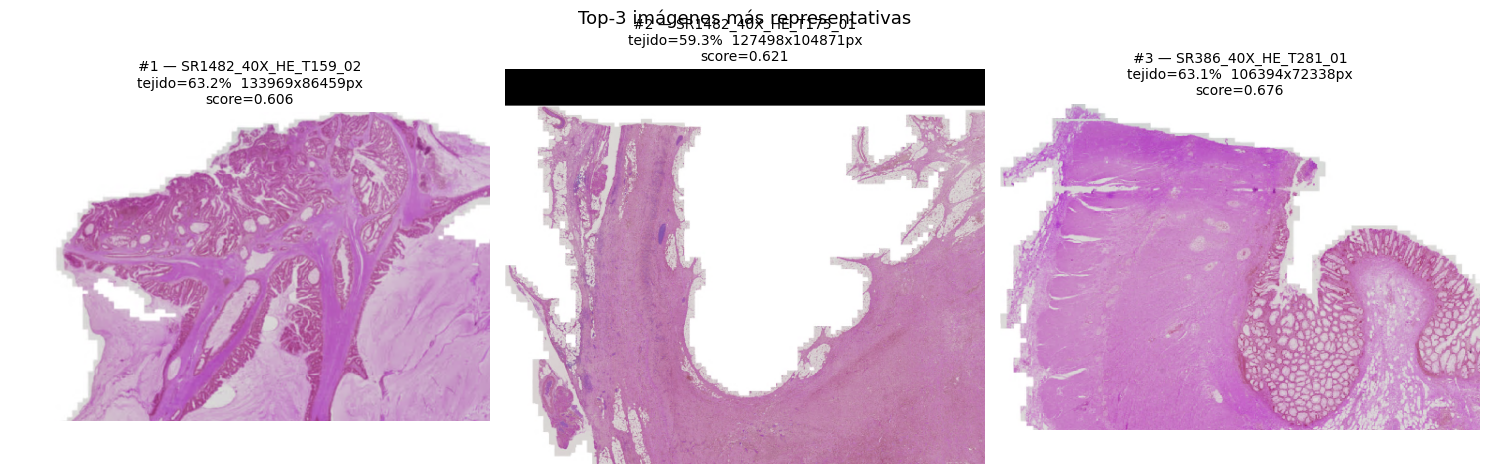


✅ Imagen seleccionada automáticamente: SR1482_40X_HE_T159_02
   Ruta: /home/shared_data/SurGen/SR1482_WSIs/SR1482_40X_HE_T159_02.czi

   Si prefieres otra, en la siguiente celda cambia SELECTED = top3[1] o top3[2]


In [26]:
# ── Visualizar miniaturas de las top-3 ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Top-3 imágenes más representativas', fontsize=13)

for i, (ax, rec) in enumerate(zip(axes, top3)):
    ax.imshow(rec['thumb'])
    ax.set_title(
        f'#{i+1} — {rec["name"]}\n'
        f'tejido={rec["tissue_pct"]:.1%}  '
        f'{rec["width"]}x{rec["height"]}px\n'
        f'score={rec["repr_score"]:.3f}',
        fontsize=10
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

# Seleccionar la #1 por defecto
SELECTED = top3[0]
print(f'\n✅ Imagen seleccionada automáticamente: {SELECTED["name"]}')
print(f'   Ruta: {SELECTED["path"]}')
print(f'\n   Si prefieres otra, en la siguiente celda cambia SELECTED = top3[1] o top3[2]')

In [27]:
# Cambia el índice: 0 = #1, 1 = #2, 2 = #3
SELECTED = top3[1]

# O especifica una ruta manualmente:
# SELECTED = {'path': '/ruta/completa/al/archivo.jpg', 'name': 'mi_archivo'}

print(f'Usando: {SELECTED["name"]}')
print(f'Ruta: {SELECTED["path"]}')

# Abrir el reader para las siguientes celdas
reader = WSIReader(SELECTED['path'], target_magnification=TARGET_MAG)
print(f'Dimensiones a {TARGET_MAG}x: {reader.dimensions[0]:,} x {reader.dimensions[1]:,} px')
print(f'Parches candidatos (sin filtro): {len(generate_patch_coords(*reader.dimensions, PATCH_SIZE)):,}')

Usando: SR1482_40X_HE_T175_01
Ruta: /home/shared_data/SurGen/SR1482_WSIs/SR1482_40X_HE_T175_01.czi
Dimensiones a 20.0x: 127,498 x 104,871 px
Parches candidatos (sin filtro): 267,330


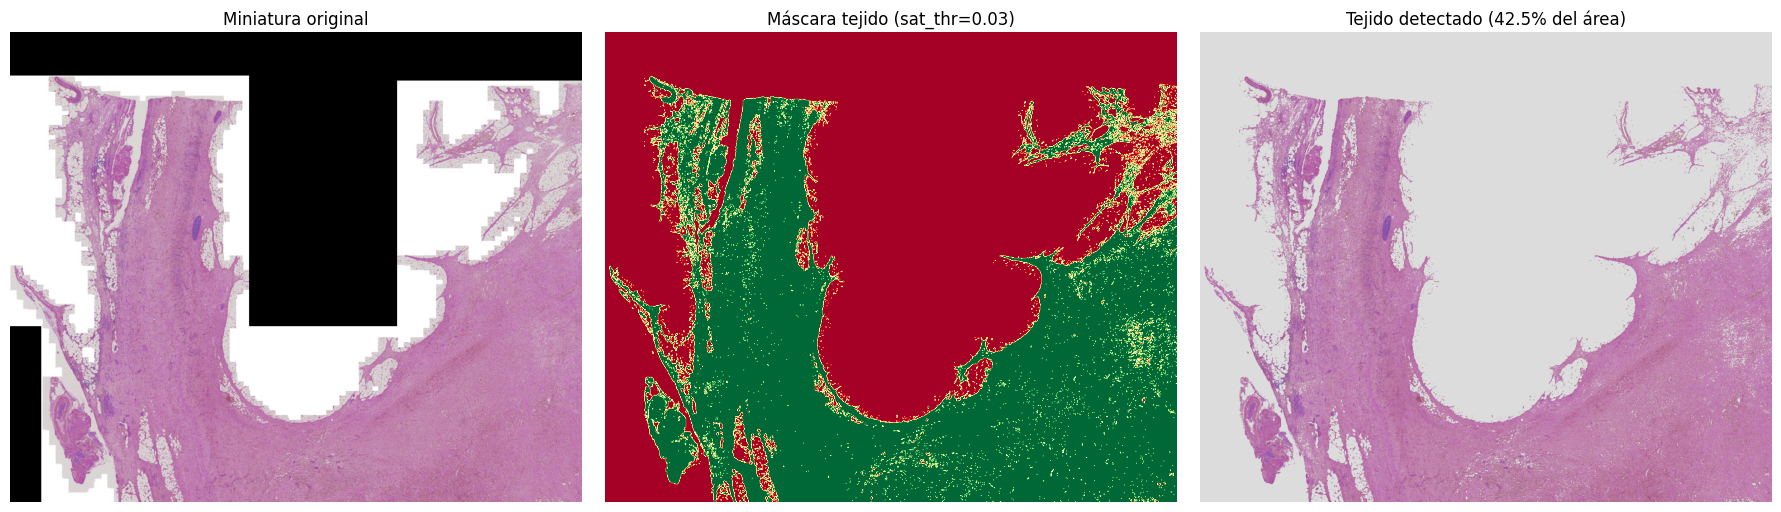


threshold       retenidos  descartados   % retenido
──────────────────────────────────────────────────
0.1               121,383      145,947        45.4%
0.2               121,383      145,947        45.4%
0.3               118,020      149,310        44.1%
0.4               118,020      149,310        44.1%
0.5               118,020      149,310        44.1%
0.8               104,533      162,797        39.1%


In [38]:
# ── Parámetros a explorar ─────────────────────────────────────────────────────
THRESHOLDS_TO_TEST = [0.1, 0.2, 0.3, 0.4,  0.5, 0.8]
SAT_FILTER         = True
SAT_THRESHOLD      = 0.03   # ajusta si la máscara no luce bien
# ─────────────────────────────────────────────────────────────────────────────

thumb = reader.get_thumbnail((1024, 1024))
mask  = compute_tissue_mask_gpu(thumb, device, SAT_FILTER, SAT_THRESHOLD).numpy()

# Máscara + overlay
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(thumb); axes[0].set_title('Miniatura original'); axes[0].axis('off')
axes[1].imshow(mask, cmap='RdYlGn', vmin=0, vmax=1)
axes[1].set_title(f'Máscara tejido (sat_thr={SAT_THRESHOLD})'); axes[1].axis('off')
overlay = thumb.copy(); overlay[~mask] = [220, 220, 220]
axes[2].imshow(overlay)
axes[2].set_title(f'Tejido detectado ({mask.mean()*100:.1f}% del área)'); axes[2].axis('off')
plt.tight_layout(); plt.show()

# Contar parches por threshold
coords_all = generate_patch_coords(*reader.dimensions, PATCH_SIZE)
W, H = reader.dimensions

print(f'\n{"threshold":<12} {"retenidos":>12} {"descartados":>12} {"% retenido":>12}')
print('─' * 50)

threshold_results = {}
for thr in THRESHOLDS_TO_TEST:
    kept, disc = [], []
    for (x, y) in coords_all:
        frac = map_patch_to_mask(x, y, PATCH_SIZE, PATCH_SIZE, W, H, mask)
        (kept if frac >= thr else disc).append((x, y, frac))
    threshold_results[thr] = {'kept': kept, 'disc': disc}
    print(f'{thr:<12.1f} {len(kept):>12,} {len(disc):>12,} {100*len(kept)/len(coords_all):>11.1f}%')

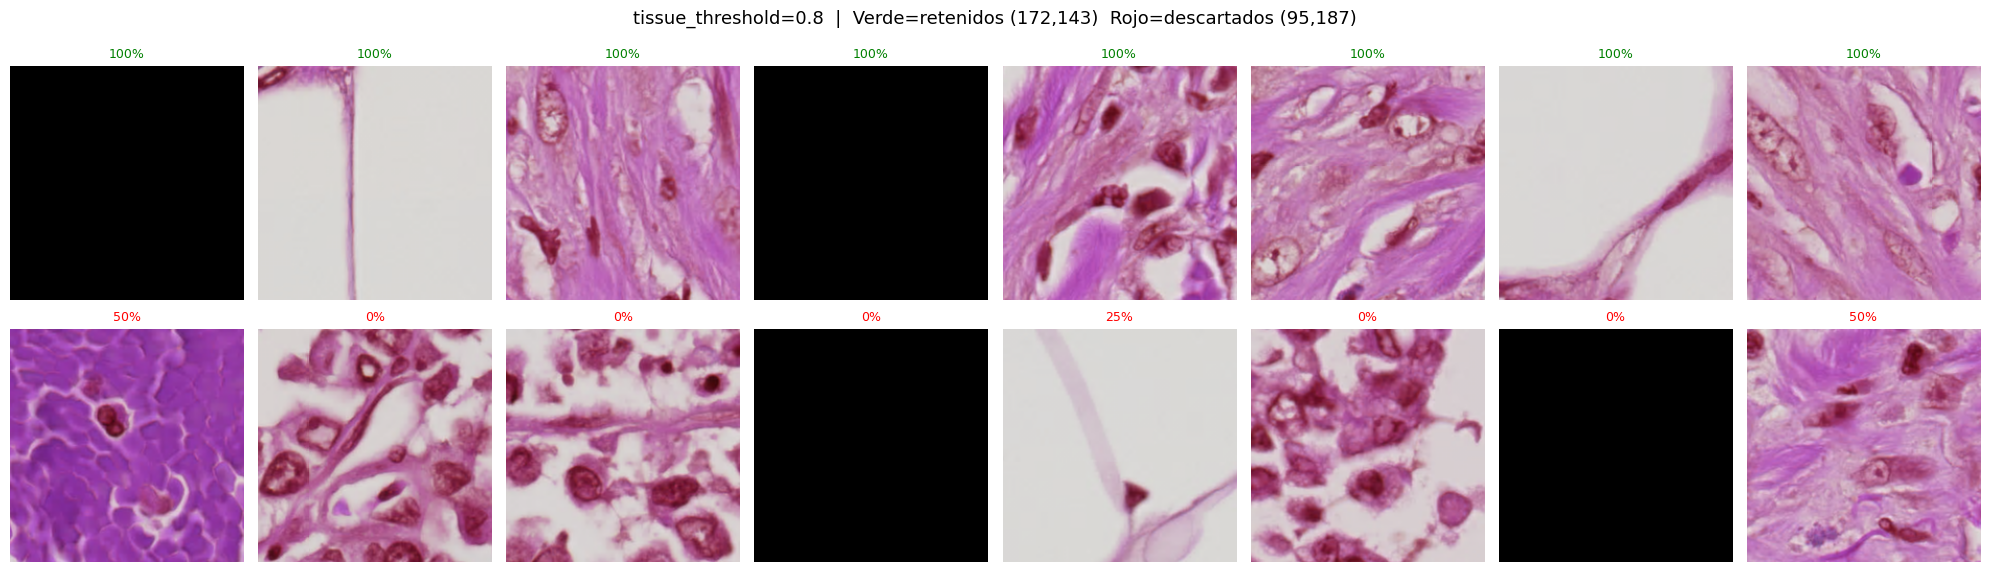

In [36]:
# ── Elige el threshold a inspeccionar visualmente ────────────────────────────
INSPECT_THRESHOLD = 0.8
N_SHOW = 8
# ─────────────────────────────────────────────────────────────────────────────

res = threshold_results[INSPECT_THRESHOLD]
sample_kept = random.sample(res['kept'], min(N_SHOW, len(res['kept'])))
sample_disc = random.sample(res['disc'], min(N_SHOW, len(res['disc'])))

fig, axes = plt.subplots(2, N_SHOW, figsize=(2.5*N_SHOW, 6))
fig.suptitle(
    f'tissue_threshold={INSPECT_THRESHOLD}  |  '
    f'Verde=retenidos ({len(res["kept"]):,})  '
    f'Rojo=descartados ({len(res["disc"]):,})',
    fontsize=13
)

for i, (x, y, frac) in enumerate(sample_kept):
    patch = reader.read_region(x, y, PATCH_SIZE, PATCH_SIZE)
    axes[0, i].imshow(patch)
    axes[0, i].set_title(f'{frac:.0%}', fontsize=9, color='green')
    axes[0, i].axis('off')
    for s in axes[0, i].spines.values(): s.set_edgecolor('green'); s.set_linewidth(3)

for i, (x, y, frac) in enumerate(sample_disc):
    patch = reader.read_region(x, y, PATCH_SIZE, PATCH_SIZE)
    axes[1, i].imshow(patch)
    axes[1, i].set_title(f'{frac:.0%}', fontsize=9, color='red')
    axes[1, i].axis('off')
    for s in axes[1, i].spines.values(): s.set_edgecolor('red'); s.set_linewidth(3)

axes[0, 0].set_ylabel('RETENIDOS', fontsize=11, color='green')
axes[1, 0].set_ylabel('DESCARTADOS', fontsize=11, color='red')
plt.tight_layout()
plt.show()

In [30]:
# ── Rellena con los valores que elegiste ─────────────────────────────────────
CHOSEN_TISSUE_THR  = 0.5
CHOSEN_SAT_THR     = 0.05
# ─────────────────────────────────────────────────────────────────────────────

yaml_block = f"""
  # {DATASET_NAME} — calibrado con imagen: {SELECTED['name']}
  # tejido mediana del dataset: {medians['tissue_pct']:.1%}
  - name: {DATASET_NAME}
    filtering:
      tissue_threshold: {CHOSEN_TISSUE_THR}
      saturation_filter: true
      saturation_threshold: {CHOSEN_SAT_THR}
"""

print('=' * 55)
print(f'  Bloque YAML para config.yaml — {DATASET_NAME}')
print('=' * 55)
print(yaml_block)

# Estadísticas finales con la configuración elegida
res_final = threshold_results.get(CHOSEN_TISSUE_THR)
if res_final:
    total = len(res_final['kept']) + len(res_final['disc'])
    print(f'  Con esta configuración:')
    print(f'  Parches retenidos : {len(res_final["kept"]):,} ({100*len(res_final["kept"])/total:.1f}%)')
    print(f'  Parches descartados: {len(res_final["disc"]):,} ({100*len(res_final["disc"])/total:.1f}%)')

  Bloque YAML para config.yaml — Surgen

  # Surgen — calibrado con imagen: SR1482_40X_HE_T175_01
  # tejido mediana del dataset: 59.3%
  - name: Surgen
    filtering:
      tissue_threshold: 0.5
      saturation_filter: true
      saturation_threshold: 0.05

  Con esta configuración:
  Parches retenidos : 118,020 (44.1%)
  Parches descartados: 149,310 (55.9%)
